In [2]:
from google.colab import drive, userdata
import os

drive.mount('/content/drive')
!pip install ultralytics -q

os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

# Create Drive folder structure immediately
os.makedirs('/content/drive/MyDrive/widerface_yolo/labels_fixed/train', exist_ok=True)
os.makedirs('/content/drive/MyDrive/widerface_yolo/labels_fixed/val', exist_ok=True)
print("Drive folder created!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive folder created!


In [3]:
!kaggle datasets download -d iamprateek/wider-face-a-face-detection-dataset
!unzip -q wider-face-a-face-detection-dataset.zip -d /content/widerface_raw
print("Download complete!")

Dataset URL: https://www.kaggle.com/datasets/iamprateek/wider-face-a-face-detection-dataset
License(s): other
100% 3.43G/3.43G [03:41<00:00, 16.6MB/s]

Download complete!


In [4]:
import cv2
import shutil

def convert_and_save(annotation_file, images_root, output_labels_dir):
    os.makedirs(output_labels_dir, exist_ok=True)
    converted = 0
    skipped = 0

    with open(annotation_file, 'r') as f:
        lines = [l.strip() for l in f.readlines()]

    i = 0
    while i < len(lines):
        if lines[i] == '':
            i += 1
            continue

        if not lines[i][0].isdigit() or '--' in lines[i]:
            img_rel_path = lines[i]
            i += 1
        else:
            i += 1
            continue

        if i >= len(lines):
            break

        try:
            num_boxes = int(lines[i])
            i += 1
        except ValueError:
            skipped += 1
            continue

        img_full_path = os.path.join(images_root, img_rel_path)
        img = cv2.imread(img_full_path)

        if img is None:
            i += max(num_boxes, 1)
            skipped += 1
            continue

        h_img, w_img = img.shape[:2]

        if num_boxes == 0:
            i += 1
            continue

        # Save directly into subfolder structure on Drive
        subfolder = img_rel_path.split('/')[0]  # e.g. '0--Parade'
        label_file = img_rel_path.split('/')[1].replace('.jpg', '.txt').replace('.png', '.txt')

        out_dir = os.path.join(output_labels_dir, subfolder)
        os.makedirs(out_dir, exist_ok=True)
        label_path = os.path.join(out_dir, label_file)

        yolo_lines = []
        for _ in range(num_boxes):
            if i >= len(lines):
                break
            parts = list(map(int, lines[i].split()))
            i += 1

            x, y, w, h = parts[0], parts[1], parts[2], parts[3]
            if w <= 0 or h <= 0:
                continue

            x_center = min(max((x + w / 2) / w_img, 0), 1)
            y_center = min(max((y + h / 2) / h_img, 0), 1)
            w_norm   = min(max(w / w_img, 0), 1)
            h_norm   = min(max(h / h_img, 0), 1)

            yolo_lines.append(f"0 {x_center:.6f} {y_center:.6f} {w_norm:.6f} {h_norm:.6f}")

        if yolo_lines:
            with open(label_path, 'w') as out_f:
                out_f.write('\n'.join(yolo_lines))
            converted += 1

    print(f"Done! Converted: {converted} | Skipped: {skipped}")

# Paths
TRAIN_ANN  = '/content/widerface_raw/wider_face_annotations/wider_face_split/wider_face_train_bbx_gt.txt'
VAL_ANN    = '/content/widerface_raw/wider_face_annotations/wider_face_split/wider_face_val_bbx_gt.txt'
TRAIN_IMGS = '/content/widerface_raw/WIDER_train/WIDER_train/images'
VAL_IMGS   = '/content/widerface_raw/WIDER_val/WIDER_val/images'

# Save directly to Drive this time
TRAIN_OUT  = '/content/drive/MyDrive/widerface_yolo/labels_fixed/train'
VAL_OUT    = '/content/drive/MyDrive/widerface_yolo/labels_fixed/val'

print("Converting TRAIN...")
convert_and_save(TRAIN_ANN, TRAIN_IMGS, TRAIN_OUT)

print("\nConverting VAL...")
convert_and_save(VAL_ANN, VAL_IMGS, VAL_OUT)

Converting TRAIN...
Done! Converted: 12876 | Skipped: 0

Converting VAL...
Done! Converted: 3222 | Skipped: 0


In [5]:
import yaml

# Images stay in /content (too large for Drive)
os.makedirs('/content/widerface_yolo/images/train', exist_ok=True)
os.makedirs('/content/widerface_yolo/images/val', exist_ok=True)

!ln -s /content/widerface_raw/WIDER_train/WIDER_train/images/* /content/widerface_yolo/images/train/
!ln -s /content/widerface_raw/WIDER_val/WIDER_val/images/* /content/widerface_yolo/images/val/

# Symlink Drive labels into /content so YOLO can find them
!ln -s /content/drive/MyDrive/widerface_yolo/labels_fixed /content/widerface_yolo/labels

# Save YAML to Drive
yaml_content = """
path: /content/widerface_yolo
train: images/train
val: images/val
names:
  0: face
"""
yaml_path = '/content/drive/MyDrive/widerface_yolo/wider_face.yaml'
with open(yaml_path, 'w') as f:
    f.write(yaml_content.strip())

print("=== VERIFY ===")
!ls /content/widerface_yolo/labels/train/ | head -3
first = !ls /content/widerface_yolo/labels/train/ | head -1
!ls /content/widerface_yolo/labels/train/{first[0]} | head -3

=== VERIFY ===
0--Parade
10--People_Marching
11--Meeting
0_Parade_marchingband_1_100.txt
0_Parade_marchingband_1_1015.txt
0_Parade_marchingband_1_1018.txt


In [6]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

results = model.train(
    data='/content/drive/MyDrive/widerface_yolo/wider_face.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    workers=2,
    name='widerface_run',
    project='/content/drive/MyDrive/widerface_yolo/runs',  # Save to Drive
    pretrained=True,
    amp=True,
    patience=10,
    save=True,
    save_period=5,  # Save checkpoint every 5 epochs
    plots=True
)

print("\n=== TRAINING COMPLETE ===")
print(f"Best model saved to: {results.save_dir}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/widerface_yolo/wider_face.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, h

In [7]:
from google.colab import drive
drive.mount('/content/drive')

from ultralytics import YOLO

# Load best model
model = YOLO('/content/drive/MyDrive/widerface_yolo/runs/widerface_run/weights/best.pt')

# Run validation
metrics = model.val(
    data='/content/drive/MyDrive/widerface_yolo/wider_face.yaml',
    split='val',
    imgsz=640,
    conf=0.3,
    iou=0.5,
    device=0
)

print("\n=== VALIDATION RESULTS ===")
print(f"Precision:  {metrics.box.mp:.4f}")
print(f"Recall:     {metrics.box.mr:.4f}")
print(f"mAP50:      {metrics.box.map50:.4f}")
print(f"mAP50-95:   {metrics.box.map:.4f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2336.8±674.4 MB/s, size: 166.2 KB)
val: Scanning /content/widerface_yolo/labels/val/0--Parade.cache... 3222 images, 4 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3226/3226 902.1Mit/s 0.0s
val: /content/widerface_yolo/images/val/21--Festival/21_Festival_Festival_21_604.jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 202/202 11.7it/s 17.2s
                   all       3226      39696      0.868      0.594      0.758      0.466
Speed: 0.5ms preprocess, 1.2ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /content/runs/detect/val

=

Testing on:
  /content/widerface_yolo/images/val/0--Parade/0_Parade_Parade_0_125.jpg
  /content/widerface_yolo/images/val/1--Handshaking/1_Handshaking_Handshaking_1_801.jpg
  /content/widerface_yolo/images/val/10--People_Marching/10_People_Marching_People_Marching_2_822.jpg

image 1/1 /content/widerface_yolo/images/val/0--Parade/0_Parade_Parade_0_125.jpg: 480x640 7 faces, 8.3ms
Speed: 2.5ms preprocess, 8.3ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /content/widerface_yolo/images/val/1--Handshaking/1_Handshaking_Handshaking_1_801.jpg: 192x640 6 faces, 65.5ms
Speed: 1.2ms preprocess, 65.5ms inference, 1.4ms postprocess per image at shape (1, 3, 192, 640)

image 1/1 /content/widerface_yolo/images/val/10--People_Marching/10_People_Marching_People_Marching_2_822.jpg: 448x640 9 faces, 64.9ms
Speed: 2.1ms preprocess, 64.9ms inference, 1.5ms postprocess per image at shape (1, 3, 448, 640)


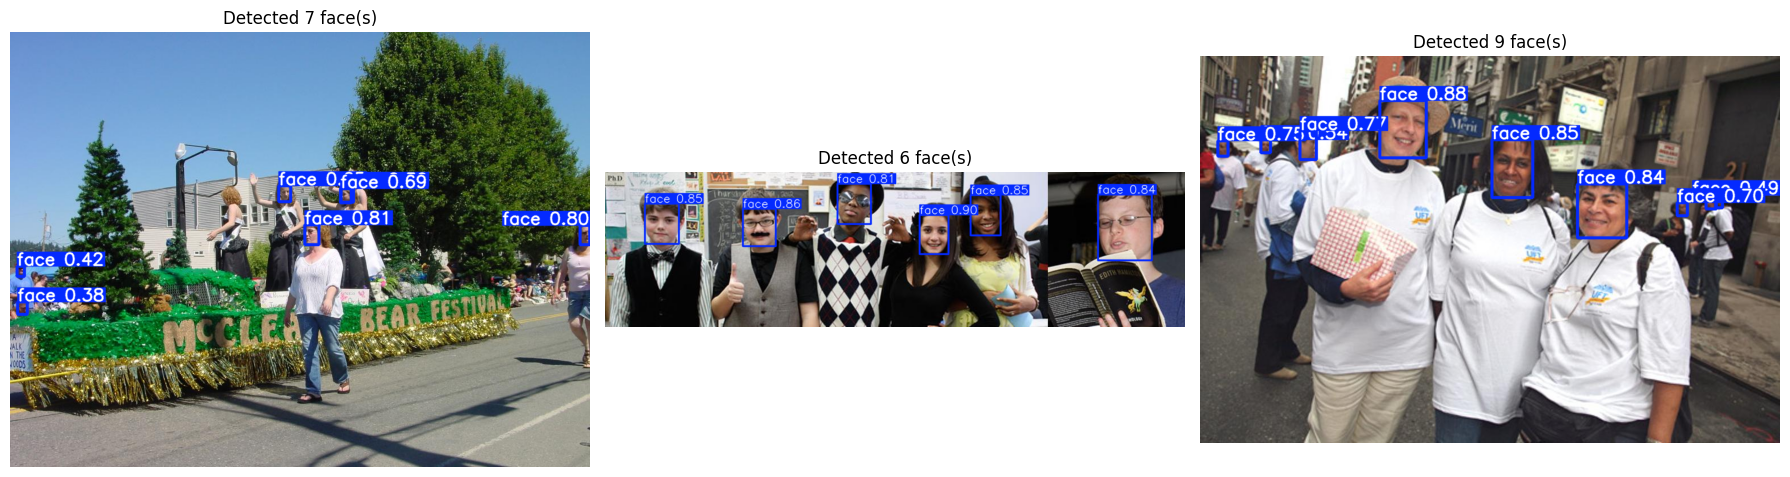

Sample saved to Drive!


In [9]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
import os

model = YOLO('/content/drive/MyDrive/widerface_yolo/runs/widerface_run/weights/best.pt')

# Dynamically pick 3 real images from the val set
val_root = '/content/widerface_yolo/images/val'
test_images = []

for folder in sorted(os.listdir(val_root))[:10]:
    folder_path = os.path.join(val_root, folder)
    images = os.listdir(folder_path)
    if images:
        test_images.append(os.path.join(folder_path, images[0]))
    if len(test_images) == 3:
        break

print("Testing on:")
for p in test_images:
    print(" ", p)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, img_path in enumerate(test_images):
    results = model(img_path, conf=0.3, device=0)
    annotated = results[0].plot()
    annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

    axes[idx].imshow(annotated_rgb)
    axes[idx].axis('off')
    num_faces = len(results[0].boxes)
    axes[idx].set_title(f'Detected {num_faces} face(s)')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/widerface_yolo/detection_sample.png', dpi=150)
plt.show()
print("Sample saved to Drive!")